# 7. 教育报告与复用

## 学习目标
为学生、教师、管理者生成证据范围内的行动建议。

**数据来源：** `aiv/data.py` 的固定种子合成样本，以及 `scripts/demo_evidence_chain.py` 的已保存合成任务标签。用于演示指标计算与报告流程。

## 运行准备
在项目环境中从干净内核运行全部单元。默认不读取 .env、不调用 API。

<!-- concept-illustration-v1:system-architecture -->
### 系统模块

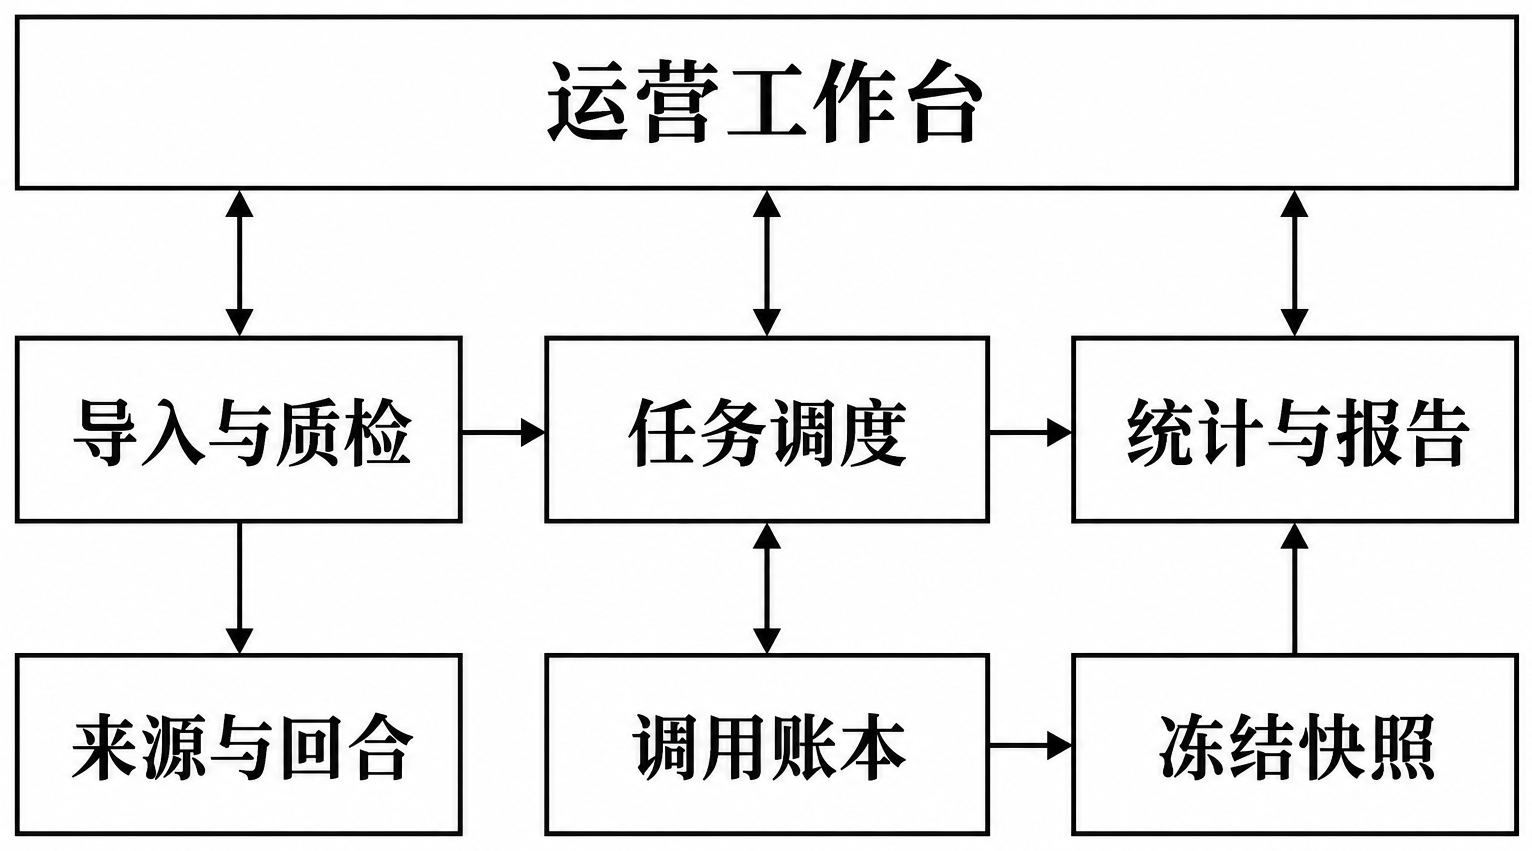

工作台组织资料、任务和报告；模型调用由调度与账本管理，冻结快照供统计和交付读取。模块图展示实现职责，不代表特定批次的运行完成状态。

In [1]:
from pathlib import Path
import sys, json

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "aiv").is_dir())
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
from aiv.data import synthetic_records

records = synthetic_records(seed=26)
LIVE_API = False  # Explicit opt-in only. Default cells never spend credits.
from aiv.notebook_materials import configure_style, save_figure
configure_style()

## 三类教育报告

In [2]:
from aiv.analysis import educational_report

reports = [
    educational_report(records, role)
    for role in ["student", "teacher", "administrator"]
]
display(pd.DataFrame(reports)[["role", "judgment", "action"]])

,role,judgment,action
0,student,现有日志可描述任务要求与过程证据；独立学习成效增量不可判断。,先独立解释一个概念，再请求反例，最后写下你采纳或拒绝建议的理由。
1,teacher,现有日志可描述任务要求与过程证据；独立学习成效增量不可判断。,安排共同锚定任务和无AI迁移题，对模型分歧样本实施盲审。
2,administrator,现有日志可描述任务要求与过程证据；独立学习成效增量不可判断。,补采处理前基础、工具可用范围、会话边界和独立后测；避免直接跨课程排名。


所有报告明示独立学习效果不可判断。建议补采的字段直接对应识别缺口。

## 复现与导出

In [3]:
manifest = {
    "seed": 26,
    "records": len(records),
    "live_api": LIVE_API,
    "source": "synthetic",
    "excluded": ["原始学生记录", "未获再分发许可的文献全文", "凭据", "私有仓库历史"],
}
display(
    pd.DataFrame(
        {"field": manifest.keys(), "value": [str(v) for v in manifest.values()]}
    )
)

,field,value
0,seed,26
1,records,192
2,live_api,False
3,source,synthetic
4,excluded,"['原始学生记录', '未获再分发许可的文献全文', '凭据', '私有仓库历史']"


公开复现材料通过白名单整理为独立仓库，包含获准发布的源码、合成样本、图文和环境说明。

## 计算检查

In [4]:
assert all(r["source"] == "synthetic" for r in reports)
assert not LIVE_API

## 继续研究
运行本页两例并检查指标、条件范围与建议；用于其他授权数据时，重新核验标签、会话边、工具来源和识别条件。

## 现场复算：资料完整与缺少证据的两例
两例共用已保存的**合成任务标签** `[2, 3, 4, 5]`，现场调用 `scripts.demo_evidence_chain.run_case` 与共享指标函数。
`complete` 具有已知合成会话边和两种工具；`missing_evidence` 将会话及工具身份设为未知。两例均不发起实时模型调用。

In [5]:
from scripts.demo_evidence_chain import run_case
from aiv.notebook_materials import configure_style, save_figure
from IPython.display import Markdown, display
configure_style()
demo_cases = {name: run_case(name) for name in ["complete", "missing_evidence"]}
demo_view = pd.DataFrame([
    {"案例": name, **case["metrics"], "AIV_balanced": case["AIV_balanced"], "条件下界": case["conditional_range"]["lower"], "条件上界": case["conditional_range"]["upper"]}
    for name, case in demo_cases.items()
])
# 保留底层 None；显示时明确写作 null，避免与零分混淆。
display(demo_view.round(4).astype(object).where(demo_view.notna(), "null"))
for name, case in demo_cases.items():
    display(Markdown(f"**{name}** · {case['report']['scope']}\n\n观察：{case['report']['observed']}\n\n行动：{case['report']['action']}"))
assert demo_cases["complete"]["source"] == demo_cases["missing_evidence"]["source"] == "synthetic_saved_labels"
assert not any(case["live_model_call"] for case in demo_cases.values())
assert demo_cases["missing_evidence"]["metrics"]["CTQ"] is None
assert demo_cases["missing_evidence"]["metrics"]["MAB"] is None
assert demo_cases["missing_evidence"]["AIV_balanced"] is None

,案例,ABL_raw,ABL,HOT,CTQ,DHI,MAB_raw,MAB,AIV_balanced,条件下界,条件上界
0,complete,3.5,0.5,0.5,0.6,0.8,2.0,0.6826,61.6521,61.6521,61.6521
1,missing_evidence,3.5,0.5,0.5,null,0.8,null,null,null,36.0,76.0


**complete** · 已保存的合成任务标签；结果用于解释计算流程。

观察：四次任务要求依次为理解、应用、分析、评价，高阶任务占一半。

行动：围绕其中一次分析任务，要求学习者补充独立推理和核验依据。

**missing_evidence** · 已保存的合成任务标签；结果用于解释计算流程。

观察：四次任务要求依次为理解、应用、分析、评价，高阶任务占一半。

行动：补充同会话相邻关系及实际工具来源后，再计算跃迁与综合分。

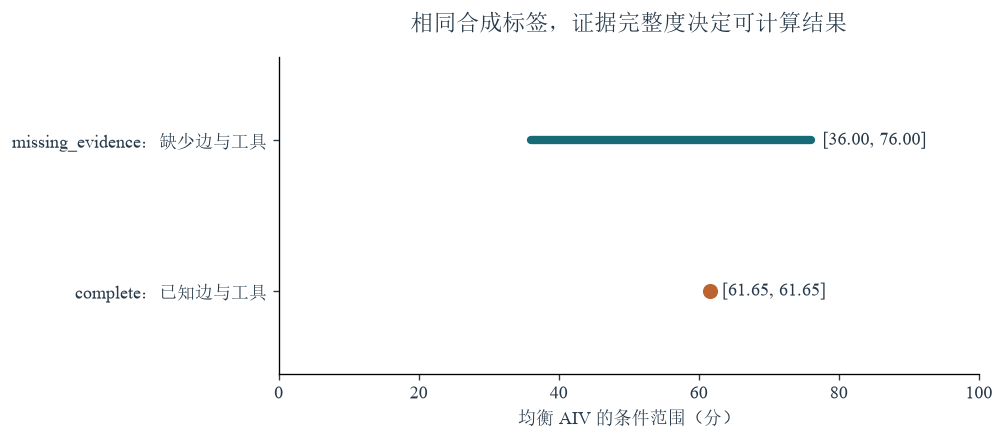

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
for y, (name, case) in enumerate(demo_cases.items()):
    bounds = case["conditional_range"]
    ax.plot([bounds["lower"], bounds["upper"]], [y, y], color="#176B77", linewidth=5, solid_capstyle="round")
    if case["AIV_balanced"] is not None:
        ax.scatter(case["AIV_balanced"], y, color="#BC632F", s=65, zorder=3)
    ax.annotate(f"[{bounds['lower']:.2f}, {bounds['upper']:.2f}]", (bounds["upper"], y), xytext=(7, 0), textcoords="offset points", va="center")
ax.set_yticks([0, 1], ["complete：已知边与工具", "missing_evidence：缺少边与工具"])
ax.set(xlim=(0, 100), ylim=(-.55, 1.55), xlabel="均衡 AIV 的条件范围（分）", title="相同合成标签，证据完整度决定可计算结果")
fig.tight_layout()
save_figure(fig, "synthetic-live-evidence-chain", "已保存合成标签的现场计算；缺少会话边和工具时保留null指标及条件范围。", kind="synthetic", sources=["scripts/demo_evidence_chain.py", "aiv/metrics.py", "aiv/models.py"], notebook="07_教育报告与复用.ipynb")
plt.show()

完整例的均衡分约为 61.65；缺证例的 CTQ、MAB 与点分均为 `null`，条件范围为 `[36, 76]`。
下一步行动对应具体缺口：完整例要求补充独立推理与核验；缺证例先补同会话关系和工具来源。
范围使用固定权重和已保存标签；合成案例展示计算与报告流程，不是对真实学习增益的估计。